# **How to understand what to find in a certain dataset?**

## **Step 1: Understand the problem:**

Q1. What am I predicting?

Number → Regression <br>
Category → Classification<br>
Groups → Clustering<br>
Example:<br>
| Target          | Problem type   | Algorithm           |
| --------------- | -------------- | ------------------- |
| House price     | Regression     | Linear Regression   |
| Pass/Fail       | Classification | Logistic Regression |
| Spam/Not spam   | Classification | Logistic Regression |
| Customer groups | Clustering     | KMeans              |

<br>
here i am finding if the species is setosa, versicolor or virginica?


## **Step 2: Check the dataset structure**

Always run:<br>
df.head()<br>
df.info()<br>
df.describe()<br>


This tells you:<br>
-Number of features<br>
-Data types<br>
-Missing values<br>
-Target column<br>

Example:<br>
sepal_length   -    float<br>
sepal_width    -   float<br>
species        -   object  ← target

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("iris.data.csv", header=None)

print(df.head())
print(df.tail())
print(df.loc[50:60])

     0    1    2    3            4
0  5.1  3.5  1.4  0.2  Iris-setosa
1  4.9  3.0  1.4  0.2  Iris-setosa
2  4.7  3.2  1.3  0.2  Iris-setosa
3  4.6  3.1  1.5  0.2  Iris-setosa
4  5.0  3.6  1.4  0.2  Iris-setosa
       0    1    2    3               4
145  6.7  3.0  5.2  2.3  Iris-virginica
146  6.3  2.5  5.0  1.9  Iris-virginica
147  6.5  3.0  5.2  2.0  Iris-virginica
148  6.2  3.4  5.4  2.3  Iris-virginica
149  5.9  3.0  5.1  1.8  Iris-virginica
      0    1    2    3                4
50  7.0  3.2  4.7  1.4  Iris-versicolor
51  6.4  3.2  4.5  1.5  Iris-versicolor
52  6.9  3.1  4.9  1.5  Iris-versicolor
53  5.5  2.3  4.0  1.3  Iris-versicolor
54  6.5  2.8  4.6  1.5  Iris-versicolor
55  5.7  2.8  4.5  1.3  Iris-versicolor
56  6.3  3.3  4.7  1.6  Iris-versicolor
57  4.9  2.4  3.3  1.0  Iris-versicolor
58  6.6  2.9  4.6  1.3  Iris-versicolor
59  5.2  2.7  3.9  1.4  Iris-versicolor
60  5.0  2.0  3.5  1.0  Iris-versicolor


In [40]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       150 non-null    float64
 1   1       150 non-null    float64
 2   2       150 non-null    float64
 3   3       150 non-null    float64
 4   4       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


,0,1,2,3
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


## **Step 3: Identify target and features**

Target = what you predict<br>
Features = inputs<br>
because in machine learning we must separate INPUT and OUTPUT

In [41]:
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]
X = df.drop("species", axis=1) #axis = 0 → vertical → rows
                               #axis = 1 → horizontal → columns
y = df["species"]

## **Step 4: Select all 4 features**
We can use 2 features (petal_length and petal_width) for learning decision boundary visualization in 2D but for best performance use all 4 features (sepal_length, sepal_width, petal_length and petal_width)
<br>
<br>
Why did you use petal features instead of sepal features?<br>
Answer: Petal features provide better class separation and have higher predictive power, which improves model accuracy and makes decision boundary visualization clearer.

# ***Using only 2 classes (setosa and versicolor)***

In [42]:
X = df[[
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]].values

y = df["species"].values

## **Step 5: Check data types**

If categorical → encode<br>
If numeric → scale<br>
The dataset has 3 classes:<br>
so we removed *virginica* leaving only *setosa* and *versicolor* <br><br>
Because we implemented this sigmoid function and Sigmoid outputs values between 0 and 1 but here we have 3 classes so we removed the third and used only 2 classes for understanding<br>
*(If we want to work with all the 3 classes then we will have to use softmax function instead of sigmoid function and multiclass logistic regression instead of binary logistic regression)*
<br><br>
we used Setosa vs Versicolor because:<br>
Setosa vs Versicolor gives clear decision boundary as <br>
Setosa       → small petal length <br>
Versicolor   → medium petal length <br>
Virginica    → larger petal length <br>

In [43]:
df = df[df["species"] != "Iris-virginica"]

df["species"] = df["species"].map({
    "setosa":0,
    "versicolor":1
})

## **Step 6: Feature scaling (ALWAYS for ML algorithms)**

Use when:<br>
-Logistic Regression<br>
-KNN<br>
-SVM<br>
-Gradient descent<br>
<br>
Scaling is needed:<br>
-Because features may have different ranges. Range difference affects learning. Model may think larger numbers are more important. Scaling fixes this.<br>
-Gradient descent works faster when features are scaled.

In [44]:
from sklearn.preprocessing import StandardScaler #StandardScaler = a tool used to scale features so they have the same range

scaler = StandardScaler() #creates a scaler object
X_scaled = scaler.fit_transform(X) #calculates Mean and Standard deviation for each feature
# X(scaled)=(X-mean)/std

## **Step 7: Split dataset**

(Always)

test_size = how much data is used for testing<br>
test_size=0.2<br>
means: <br>
20% data → testing<br>
80% data → training<br>
<br>
Example for 100 rows:
| test_size | training data | testing data |
| --------- | ------------- | ------------ |
| 0.2       | 80 rows       | 20 rows      |
| 0.3       | 70 rows       | 30 rows      |
| 0.1       | 90 rows       | 10 rows      |

<br>random_state = when splitting, sklearn randomly selects which rows go into training and testing<br>
It keeps the accuracy same throughout the training period

In [45]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

## **Step 8: Choose algorithm based on problem**
Regression problem:
<br>
-LinearRegression()<br>
-RandomForestRegressor()


Classification problem:
<br>
-LogisticRegression()<br>
-DecisionTreeClassifier()<br>
-RandomForestClassifier()<br>

## **Step 9: Train, Predict and Evaluate the model**

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, log_loss
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder

#train
model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

#evaluate
#we do not use r2_score and mean_squared_error for Logistic Regression
acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)

conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", conf_matrix)

precision = precision_score(y_test, y_pred, average='weighted')
print("Precision:", precision) #Correct positive predictions/Total predicted positives

recall = recall_score(y_test, y_pred, average='weighted')
print("Recall:", recall) #Correct positive predictions/Total actual positives

f1 = f1_score(y_test, y_pred, average='weighted')
print("F1 Score:", f1) #F1 = balance between precision and recall

#predict probabilities for log_loss
y_pred_proba = model.predict_proba(X_test)
logloss = log_loss(y_test, y_pred_proba)
print("Log Loss:", logloss)

Accuracy Score: 1.0
Confusion Matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Precision: 1.0
Recall: 1.0
F1 Score: 1.0
Log Loss: 0.12128667658708808



Basically,<br>
 .fit model uses:<br>
-Uses sigmoid function<br>
-Uses cost function (Log Loss)<br>
-Uses gradient descent (or similar optimizer)<br>
<br>
.predict model uses:<br>
Step 1:Calculate z: z=Xw+b

Step 2: Apply sigmoid:
probability=sigmoid(z)

Step 3: Apply threshold:<br>
if probability ≥ 0.5 → class 1 <br>
else → class 0

## **Step 10: Decision boundary**

When to plot decision boundary?<br>

Use when:<br>
-Classification problem<br>
-Dataset has 2 features<br>
-You want visualization<br>
-For understanding or presentation<br>
(Not always required)

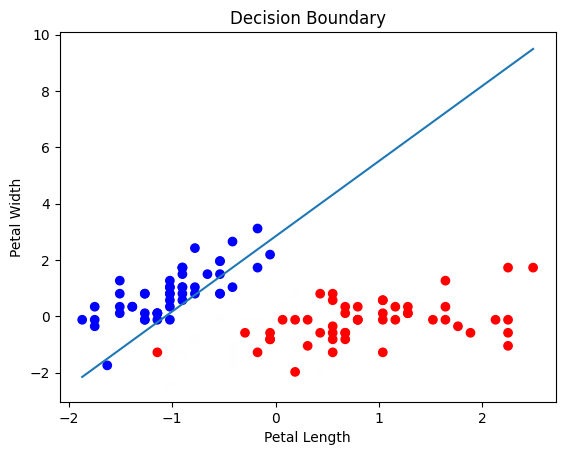

In [62]:
plt.scatter(
    X_scaled[:,0], #all values of Feature 1 (x-axis)
    X_scaled[:,1], #all values of Feature 2 (y-axis)
    c=y, #color based on class
    cmap="bwr" #color map: blue = class 0 and red = class 1
)
#Blue dots → Setosa
#Red dots → Versicolor

x_values = np.array([X_scaled[:,0].min(), X_scaled[:,0].max()]) #This creates 2 points: minimum x value and maximum x value
                                                                #We need these to draw a line across full graph

y_values = -(w[0]*x_values + b)/w[1] #It comes from logistic regression equation: z = w1*x1 + w2*x2 + b
                                     #Decision boundary exists where: z = 0
                                     #So: w1*x1 + w2*x2 + b = 0
                                     #Solve for x2: x2 = -(w1*x1 + b) / w2
                                     #This gives the line equation

plt.plot(x_values, y_values) #line is where model predicts probability = 0.5

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.title("Decision Boundary")

plt.show()

Decision boundary is possible till 3 classes (or features) <br>
but not for more than 3 (it is difficult for 3 classes but easy and clear till 2classes)

## **Step 11: Overfitting vs Underfitting**

When to check Overfitting vs Underfitting?<br>
Check this when:<br>
-You are building a model for real use<br>
-You trained the model<br>
-You want to know if model is reliable<br>
You ALWAYS check this in real projects

In [63]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

#Simple model → less flexible → lower overfitting risk
#Complex model → very flexible → high overfitting risk

# simple model
model_simple = LogisticRegression()
model_simple.fit(X_train, y_train)

# complex model (overfitting prone)
poly = PolynomialFeatures(degree=5)

X_poly_train = poly.fit_transform(X_train)
X_poly_test = poly.transform(X_test)

model_complex = LogisticRegression(max_iter=10000)
model_complex.fit(X_poly_train, y_train)

print("Simple model accuracy:",
      model_simple.score(X_test, y_test))

print("Complex model accuracy:",
      model_complex.score(X_poly_test, y_test))

#complex model here has 0.03 lower accuracy than simple model
#Overfitting means: Model memorizes training data too much.

Simple model accuracy: 0.9666666666666667
Complex model accuracy: 0.9333333333333333


## **Step 12: Model comparison (your model vs sklearn)**

When to compare models?<br>
Use when: You want best model<br>
Example: Logistic vs Decision Tree vs Random Forest

In [64]:
from sklearn.linear_model import LogisticRegression

sk_model = LogisticRegression()

sk_model.fit(X_train, y_train)

print("Your model accuracy:",
      np.mean(y_pred == y_test)) #line checks how many predictions are correct

print("Sklearn model accuracy:",
      sk_model.score(X_test, y_test))

Your model accuracy: 0.6
Sklearn model accuracy: 0.9666666666666667


Like if you see above, we eliminated *virginica* and used only 2 classes for binary logistic regression and sigmoid function <br>
but if we want to use all 3 classes setosa, versicolor and virginica then there are no major changes as the .fit and .predict commands itself changes the binary logistic regression to multinomial logistic regression and sigmoid function to softmax function (refer code below for understanding):

# ***Using all 3 classes (setosa, versicolor and Virginica)***

In [48]:
#if using all 3 classes setosa, versicolor and virginica then:

# load dataset
df = pd.read_csv("iris.data.csv", header=None)

# Assign column names
df.columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width",
    "species"
]

# convert species to numbers
df["species"] = df["species"].map({
    "Iris-setosa":0,
    "Iris-versicolor":1,
    "Iris-virginica":2
})

# features and target
X = df.drop("species", axis=1)
y = df["species"]

# scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2
)

# train model (softmax used automatically)
model = LogisticRegression()

model.fit(X_train, y_train)

# predict
y_pred = model.predict(X_test)

print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.9666666666666667


# **Concepts for understanding only**

**If output continuous number --> Regression** <br>
Examples: <br>
-Price = 50000 <br>
-CPU usage = 73.5% <br>
-Temperature = 28.3°C<br>
use: r2_Score and mse  (for numbers)
<br><br>
**If output category/class --> Classification**<br>
Examples:<br>
-Spam / Not Spam<br>
-Yes / No<br>
-Setosa / Versicolor / Virginica<br>
use: accuracy_score and confusion_matrix (for category)

### **1] Sigmoid function**

In [52]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### **2] Cost Function**

In [53]:
def cost_function(X, y, w, b):

    n = len(y)

    z = np.dot(X, w) + b
    y_pred = sigmoid(z)

    cost = -(1/n) * np.sum(
        y*np.log(y_pred) + (1-y)*np.log(1-y_pred)
    )

    return cost

### **3] Gradient Descent**

In [54]:
def gradient_descent(X, y, w, b, learning_rate, epochs):

    n = len(y)

    costs = []

    for i in range(epochs):

        z = np.dot(X, w) + b
        y_pred = sigmoid(z)

        dw = (1/n) * np.dot(X.T, (y_pred - y))
        db = (1/n) * np.sum(y_pred - y)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        cost = cost_function(X, y, w, b)
        costs.append(cost)

    return w, b, costs

### **4] Model Training**

In [59]:
# initialize weights
w = np.zeros(X_train.shape[1])
b = 0

# train model
w, b, costs = gradient_descent(
    X_train, y_train, w, b,
    learning_rate=0.1,
    epochs=100
)

print("Final weights:", w)
print("Final bias:", b)

Final weights: [ 3.3616699  -1.25892932  3.67427205  3.67833118]
Final bias: 3.5728692199095424


### **5] Plot Cost vs Epoch**

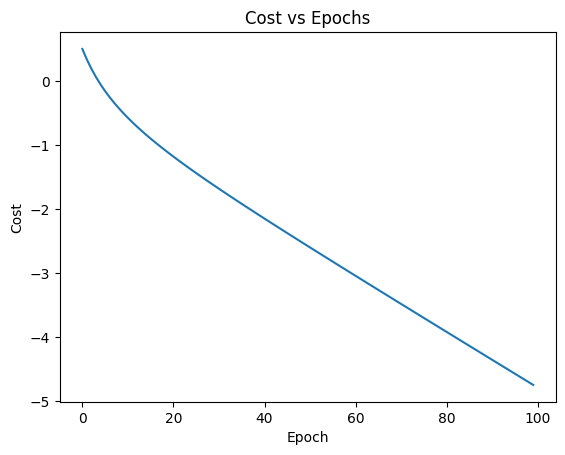

In [60]:
plt.plot(costs)
plt.title("Cost vs Epochs")
plt.xlabel("Epoch")
plt.ylabel("Cost")
plt.show()

### **6] Prediction and Accuracy**

In [61]:
def predict(X, w, b):

    z = np.dot(X, w) + b
    probs = sigmoid(z)

    return (probs >= 0.5).astype(int)

y_pred = predict(X_test, w, b)

accuracy = np.mean(y_pred == y_test)
print("Accuracy:", accuracy)

Accuracy: 0.6


### **7] Softmax Function**

In [65]:
import numpy as np

def softmax(z):

    # prevent overflow
    z_stable = z - np.max(z, axis=1, keepdims=True)

    exp_z = np.exp(z_stable)

    probabilities = exp_z / np.sum(exp_z, axis=1, keepdims=True)

    return probabilities

z = np.array([[2.0, 1.0, 0.1]])
print(softmax(z))

[[0.65900114 0.24243297 0.09856589]]
